In [ ]:
import pandas as pd
import numpy as np

# ML libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

# Load final datasets
train_df = pd.read_csv('final_train.csv')
test_df = pd.read_csv('final_test.csv')

# Drop rows with any NaN values to ensure clean data for all models
initial_train_shape = train_df.shape
initial_test_shape = test_df.shape

train_df.dropna(inplace=True)
test_df.dropna(inplace=True)

print("✅ Final datasets loaded and NaNs handled successfully!")
print(f"Original Train shape: {initial_train_shape}, New Train shape: {train_df.shape}")
print(f"Original Test shape: {initial_test_shape}, New Test shape: {test_df.shape}")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
train_df.head()

✅ Final datasets loaded and NaNs handled successfully!
Original Train shape: (52000, 42), New Train shape: (52000, 42)
Original Test shape: (13000, 42), New Test shape: (13000, 42)
Train shape: (52000, 42)
Test shape: (13000, 42)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class
0,-131.038772,udp,domain_u,SF,20670.347854,3406.812917,-0.000160,0.011815,0.000261,0.024261,...,258.997743,1.029418,0.002965,0.012662,-0.002226,0.013094,-0.026111,0.006095,-0.041126,normal
1,-230.547799,tcp,private,S0,-85880.275594,-3805.490307,-0.000356,0.018846,0.000275,0.176190,...,15.657866,0.039687,0.047815,0.009440,0.006140,1.016719,1.009325,0.014897,0.022317,anomaly
2,13.942000,tcp,netbios_ns,S0,-248967.849264,3207.361029,-0.000022,-0.000988,0.000232,-0.061581,...,9.917148,0.035070,0.046870,0.014693,0.014714,0.987408,0.979076,-0.013503,-0.021465,anomaly
3,26.049747,tcp,http,SF,-47724.845930,-1571.809186,0.000985,0.000021,0.000504,-0.017244,...,270.923858,1.030846,-0.027376,0.056350,0.035422,0.021282,0.049234,0.009626,0.014552,normal
4,-55.678075,tcp,http,SF,-150978.735837,7595.898521,-0.000010,0.007097,-0.000238,0.027555,...,259.168577,0.972819,-0.009242,0.037311,0.075919,-0.034902,0.018902,0.012705,0.007488,normal


In [ ]:
from sklearn.preprocessing import LabelEncoder

target_col = 'class'

X_train = train_df.drop(columns=[target_col])
y_train = train_df[target_col]
X_test = test_df.drop(columns=[target_col])
y_test = test_df[target_col]

# Encode categorical features
cat_cols = X_train.select_dtypes(include=['object']).columns
encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col])
    encoders[col] = le

# ==========================
# 🟡 Encode target labels
# ==========================
target_encoder = LabelEncoder()
y_train = target_encoder.fit_transform(y_train)
y_test = target_encoder.transform(y_test)

print("✅ Data preprocessing and encoding complete!")


✅ Data preprocessing and encoding complete!


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Feature scaling complete!")


✅ Feature scaling complete!


In [ ]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)
log_pred = log_model.predict(X_test_scaled)

log_acc = accuracy_score(y_test, log_pred)
print("🔹 Logistic Regression Accuracy:", round(log_acc * 100, 2), "%")


🔹 Logistic Regression Accuracy: 88.46 %


In [ ]:
tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)
tree_pred = tree_model.predict(X_test)

tree_acc = accuracy_score(y_test, tree_pred)
print("🔹 Decision Tree Accuracy:", round(tree_acc * 100, 2), "%")


🔹 Decision Tree Accuracy: 83.48 %


In [ ]:
# =========================
# Random Forest
# =========================

rf_model = RandomForestClassifier(
    n_estimators=100,      # number of trees
    random_state=42,
    n_jobs=-1              # use all CPU cores
)

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)
print("🔹 Random Forest Accuracy:", round(rf_acc * 100, 2), "%")

🔹 Random Forest Accuracy: 91.73 %


In [ ]:
from sklearn.svm import SVC

svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train_scaled, y_train)
svm_pred = svm_model.predict(X_test_scaled)

svm_acc = accuracy_score(y_test, svm_pred)
print("🔹 SVM Accuracy:", round(svm_acc * 100, 2), "%")

print("\n📊 Classification Report (SVM):\n", classification_report(y_test, svm_pred))


🔹 SVM Accuracy: 91.32 %

📊 Classification Report (SVM):
               precision    recall  f1-score   support

           0       0.91      0.90      0.91      6147
           1       0.91      0.92      0.92      6853

    accuracy                           0.91     13000
   macro avg       0.91      0.91      0.91     13000
weighted avg       0.91      0.91      0.91     13000



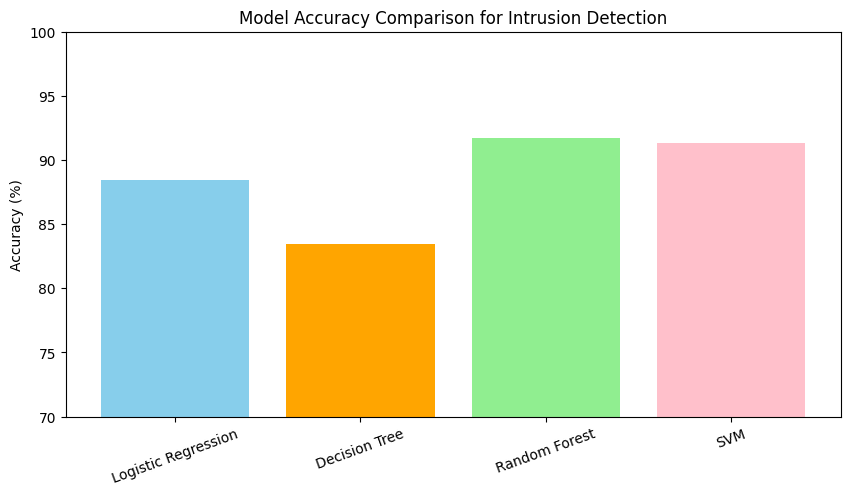

In [ ]:
models = ['Logistic Regression', 'Decision Tree', 'Random Forest', 'SVM']
accuracies = [
    log_acc * 100,
    tree_acc * 100,
    rf_acc * 100,
    svm_acc * 100,

]

plt.figure(figsize=(10, 5))
plt.bar(models, accuracies,
        color=['skyblue', 'orange', 'lightgreen', 'pink'])
plt.ylabel('Accuracy (%)')
plt.title('Model Accuracy Comparison for Intrusion Detection')
plt.ylim(70, 100)
plt.xticks(rotation=20)
plt.show()


In [ ]:
# Dictionary of model accuracies (make sure these variables already exist)
model_scores = {
    "Logistic Regression": log_acc,
    "Decision Tree": tree_acc,
    "Random Forest": rf_acc,
    "SVM": svm_acc,

}

# Find the best model
best_model = max(model_scores, key=model_scores.get)
best_score = model_scores[best_model] * 100

print("\nBest Model Selected")
print(f"Best Model: {best_model}")
print(f"Accuracy Achieved: {best_score:.2f}%")




Best Model Selected
Best Model: Random Forest
Accuracy Achieved: 91.73%


In [ ]:
import joblib

# Save Random Forest model
joblib.dump(rf_model, "rf_model.pkl")

# Save encoders (important for categorical columns)
joblib.dump(encoders, "encoders.pkl")

# Save feature column order
joblib.dump(X_train.columns.tolist(), "features.pkl")

print("Model and preprocessing saved successfully!")

Model and preprocessing saved successfully!
